In [1]:
import os
import torch
import timm
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4


CLASS_NAMES = ['Mayo_0','Mayo_1','Mayo_2','Mayo_3']


TEST_ROOT = r"D:/Project/LIMUC/LIMUC/test_set/test_set"
MODEL_PATH = "best_effresnetvit_ordinal.pth"

In [2]:
# -------------------- CELL 2: MODEL DEFINITION (ORDINAL) --------------------
class EFFResNetViTOrdinal(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.eff = timm.create_model('efficientnet_b4', pretrained=False, features_only=True)
        self.res = timm.create_model('resnet50', pretrained=False, features_only=True)
        eff_dim = self.eff.feature_info[-1]['num_chs']
        res_dim = self.res.feature_info[-1]['num_chs']
        self.fusion = nn.Conv2d(eff_dim + res_dim, 768, kernel_size=1)
        enc = nn.TransformerEncoderLayer(d_model=768, nhead=12, dim_feedforward=3072, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=2)
        self.ordinal_head = nn.Linear(768, num_classes-1)
    def forward(self, x):
        eff = self.eff(x)[-1]
        res = self.res(x)[-1]
        fused = torch.cat([eff, res], dim=1)
        t = self.fusion(fused)
        t = t.flatten(2).transpose(1,2)
        t = self.transformer(t)
        pooled = t.mean(dim=1)
        return self.ordinal_head(pooled)

# -------------------- CELL 3: LOAD MODEL --------------------
model = EFFResNetViTOrdinal(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print('✓ Ordinal model loaded')


✓ Ordinal model loaded


In [5]:
# -------------------- CELL 4: DATASET & DATALOADER --------------------
transform = transforms.Compose([
transforms.Resize((IMG_SIZE, IMG_SIZE)),
transforms.ToTensor(),
transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
])


test_ds = datasets.ImageFolder(TEST_ROOT, transform=transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
print('Classes:', test_ds.classes)


# -------------------- CELL 5: HELPER FUNCTIONS --------------------
def logits_to_label(logits):
    probs = torch.sigmoid(logits)
    return (probs > 0.5).sum(dim=1).long()



Classes: ['Mayo 0', 'Mayo 1', 'Mayo 2', 'Mayo 3']


Test Accuracy: 0.7544
Test QWK:      0.8282


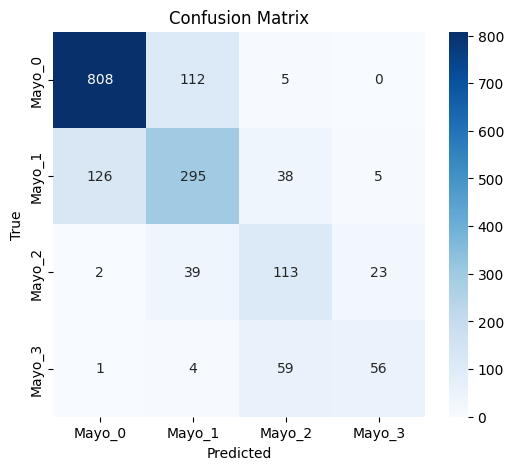


Classification Report:

              precision    recall  f1-score   support

      Mayo_0       0.86      0.87      0.87       925
      Mayo_1       0.66      0.64      0.65       464
      Mayo_2       0.53      0.64      0.58       177
      Mayo_3       0.67      0.47      0.55       120

    accuracy                           0.75      1686
   macro avg       0.68      0.65      0.66      1686
weighted avg       0.76      0.75      0.75      1686

Per-class Sensitivity & Specificity:

Mayo_0: Recall=0.8735, Specificity=0.8305
Mayo_1: Recall=0.6358, Specificity=0.8732
Mayo_2: Recall=0.6384, Specificity=0.9324
Mayo_3: Recall=0.4667, Specificity=0.9821


In [6]:


# -------------------- CELL 6: TEST EVALUATION --------------------
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        preds = logits_to_label(logits)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
acc = (y_true == y_pred).mean()
print(f"Test Accuracy: {acc:.4f}")
print(f"Test QWK:      {qwk:.4f}")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print('\nClassification Report:\n')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

print('Per-class Sensitivity & Specificity:\n')
for i, name in enumerate(CLASS_NAMES):
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    recall = TP / (TP + FN + 1e-8)
    spec = TN / (TN + FP + 1e-8)
    print(f"{name}: Recall={recall:.4f}, Specificity={spec:.4f}")



In [8]:
# -------------------- CELL 7: SCORE-CAM IMPLEMENTATION --------------------
class ScoreCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        target_layer.register_forward_hook(self._hook)
    def _hook(self, m, i, o):
        self.activations = o.detach()
    def generate(self, x, class_idx, max_maps=32):
        _ = self.model(x)
        maps = torch.relu(self.activations[0])
        cam = np.zeros((IMG_SIZE, IMG_SIZE))
        for i in range(min(max_maps, maps.shape[0])):
            m = maps[i]
            m = (m - m.min()) / (m.max() - m.min() + 1e-8)
            m_up = cv2.resize(m.cpu().numpy(), (IMG_SIZE, IMG_SIZE))
            masked = x * torch.tensor(m_up, device=DEVICE).unsqueeze(0).unsqueeze(0)
            with torch.no_grad():
                score = torch.sigmoid(self.model(masked))[0].mean().item()
            cam += score * m_up
        cam = cam / (cam.max() + 1e-8)
        return cam


Prediction: Mayo_3
Cumulative probs: [0.9992798 0.9997421 0.7950979]


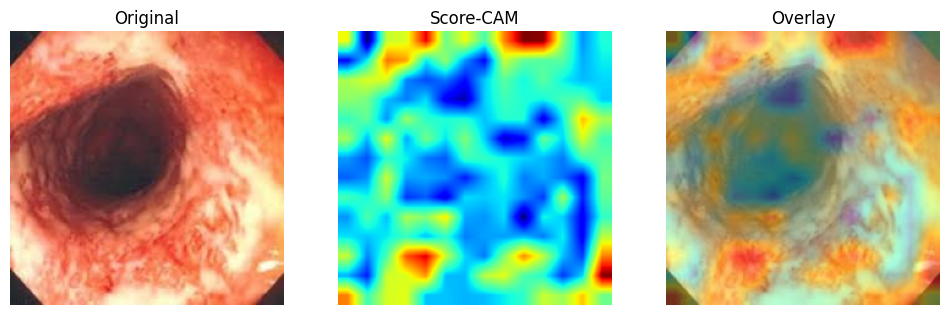

In [10]:
# -------------------- CELL 8: SINGLE IMAGE PREDICTION + SCORE-CAM --------------------
def explain_single_image(image_path):
    img = Image.open(image_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0]
        pred = int((probs > 0.5).sum().item())
    print(f"Prediction: {CLASS_NAMES[pred]}")
    print(f"Cumulative probs: {probs.cpu().numpy()}")
    scorecam = ScoreCAM(model, model.eff.blocks[4])
    cam = scorecam.generate(x, pred)
    img_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    heat = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.65*img_np + 0.35*heat)
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img_np); plt.title('Original'); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(cam, cmap='jet'); plt.title('Score-CAM'); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(overlay); plt.title('Overlay'); plt.axis('off')
    plt.show()

# -------------------- CELL 9: RUN XAI --------------------
# Example:
explain_single_image(r"C:\Users\ADMIN\Desktop\download.jpg")
